In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [2]:
# Display settings
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("/Users/skush/CodeX/Stress-Level-Classifier/data/processed/structured_responses.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.head()

,Age,Gender,Occupation,Device_Type,Work_Productivity_Score,Weekend_Screen_Time_Hours,Daily_Phone_Hours,Sleep_Hours,Social_Media_Hours,Stress_Level,Caffeine_Intake_Cups
0,22,Male,Student,iOS,6,4.0,4.0,7.0,1.5,7,3
1,23,Female,Student,iOS,9,2.5,2.0,7.0,0.5,2,0
2,23,Female,Student;Professional,iOS,6,6.0,4.0,7.5,3.0,4,3
3,23,Male,Student,iOS,6,4.5,3.0,8.0,2.0,5,1
4,24,Female,Student,iOS,10,9.0,7.0,6.5,5.0,7,0


In [5]:
# Data types
print("Data Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n")
df.describe()

Data Types:

Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Work_Productivity_Score        int64
Weekend_Screen_Time_Hours    float64
Daily_Phone_Hours            float64
Sleep_Hours                  float64
Social_Media_Hours           float64
Stress_Level                   int64
Caffeine_Intake_Cups           int64
dtype: object

Missing Values:

Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Work_Productivity_Score      0
Weekend_Screen_Time_Hours    0
Daily_Phone_Hours            0
Sleep_Hours                  0
Social_Media_Hours           0
Stress_Level                 0
Caffeine_Intake_Cups         0
dtype: int64

Summary Statistics:



,Age,Work_Productivity_Score,Weekend_Screen_Time_Hours,Daily_Phone_Hours,Sleep_Hours,Social_Media_Hours,Stress_Level,Caffeine_Intake_Cups
count,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000,61.000000
mean,25.016393,6.672131,6.245902,5.852459,7.131148,2.860656,6.426230,1.606557
std,4.818339,1.841388,2.799737,2.731520,1.378108,1.945360,2.283703,1.800728
min,18.000000,1.000000,2.000000,1.500000,2.500000,0.500000,1.000000,0.000000
25%,22.000000,6.000000,4.000000,3.500000,6.500000,1.500000,5.000000,0.000000
50%,23.000000,6.000000,6.000000,6.000000,7.000000,3.000000,7.000000,1.000000
75%,28.000000,8.000000,8.000000,7.500000,8.000000,3.500000,8.000000,2.000000
max,45.000000,10.000000,13.500000,13.000000,10.000000,11.000000,10.000000,10.000000


<h3> Target Variable Analysis

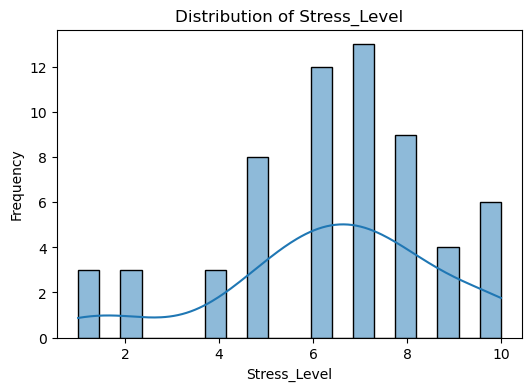

Skewness: -0.6022716813969011
Kurtosis: 0.17755553271072122

Summary:
 count    61.000000
mean      6.426230
std       2.283703
min       1.000000
25%       5.000000
50%       7.000000
75%       8.000000
max      10.000000
Name: Stress_Level, dtype: float64


In [6]:
# Histogram + KDE
plt.figure(figsize=(6,4))
sns.histplot(df["Stress_Level"], bins=20, kde=True)
plt.title("Distribution of Stress_Level")
plt.xlabel("Stress_Level")
plt.ylabel("Frequency")
plt.show()

# Statistical moments
stress_skew = skew(df["Stress_Level"])
stress_kurt = kurtosis(df["Stress_Level"])

print("Skewness:", stress_skew)
print("Kurtosis:", stress_kurt)
print("\nSummary:\n", df["Stress_Level"].describe())

<h3> Feature Distribution Diagnostics

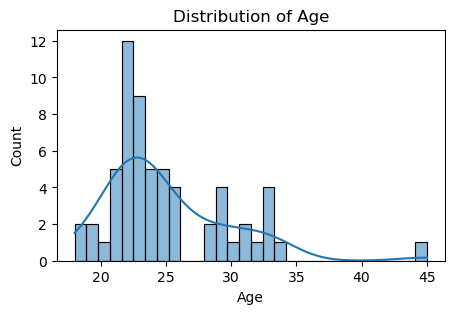

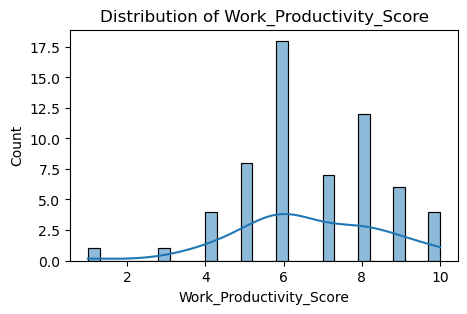

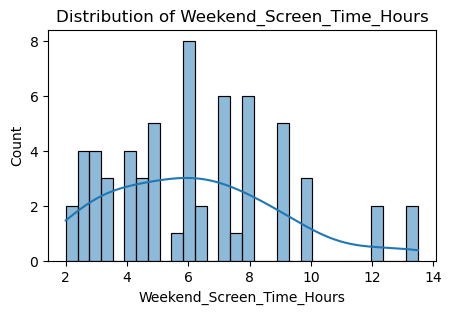

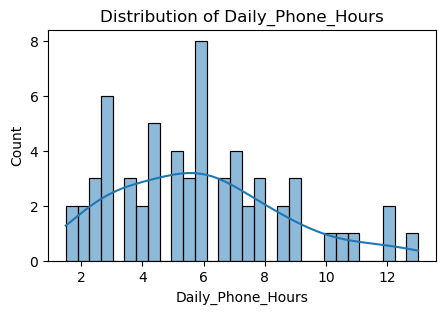

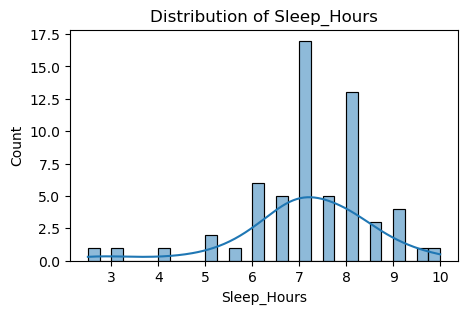

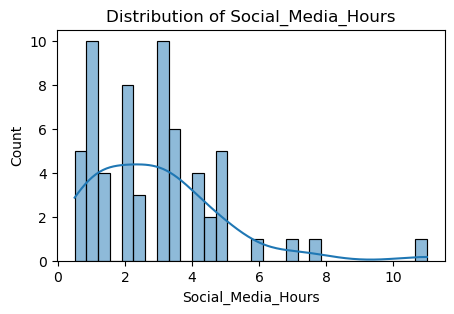

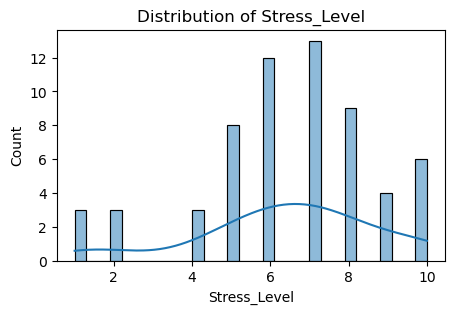

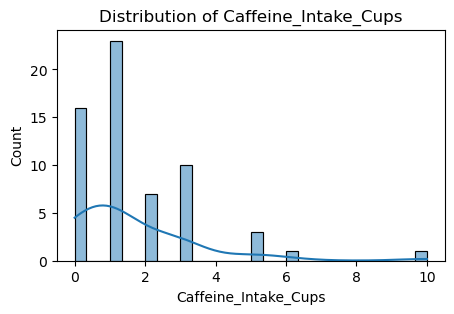

In [7]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

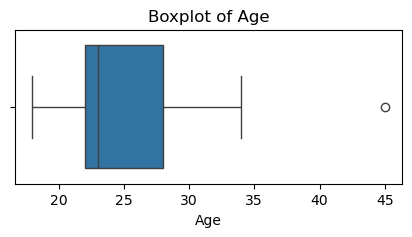

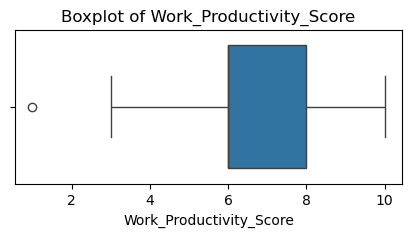

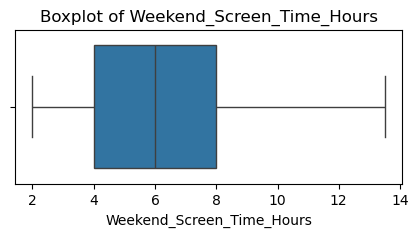

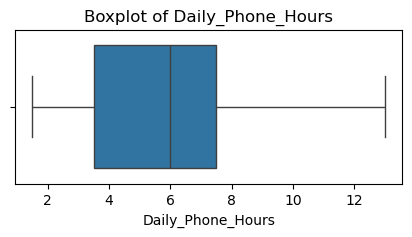

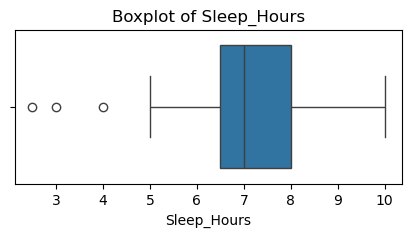

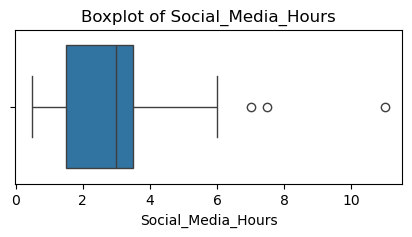

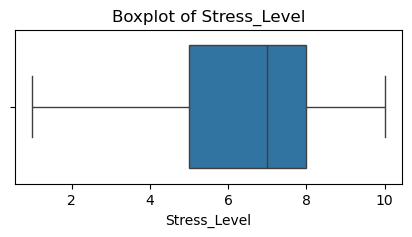

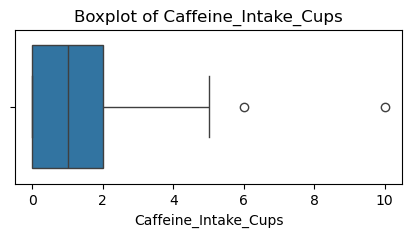

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<h3> Treating Outliers 

In [9]:
df.shape

(61, 11)

In [10]:
df = df[df["Age"] != 45]
df = df[df["Work_Productivity_Score"] > 2]
df = df[df["Sleep_Hours"] > 3]
df = df[df["Caffeine_Intake_Cups"] <= 8]

In [11]:
df.shape

(56, 11)

In [12]:
df.to_csv("/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_survey_responses.csv")

<h3> Correlation Analysis

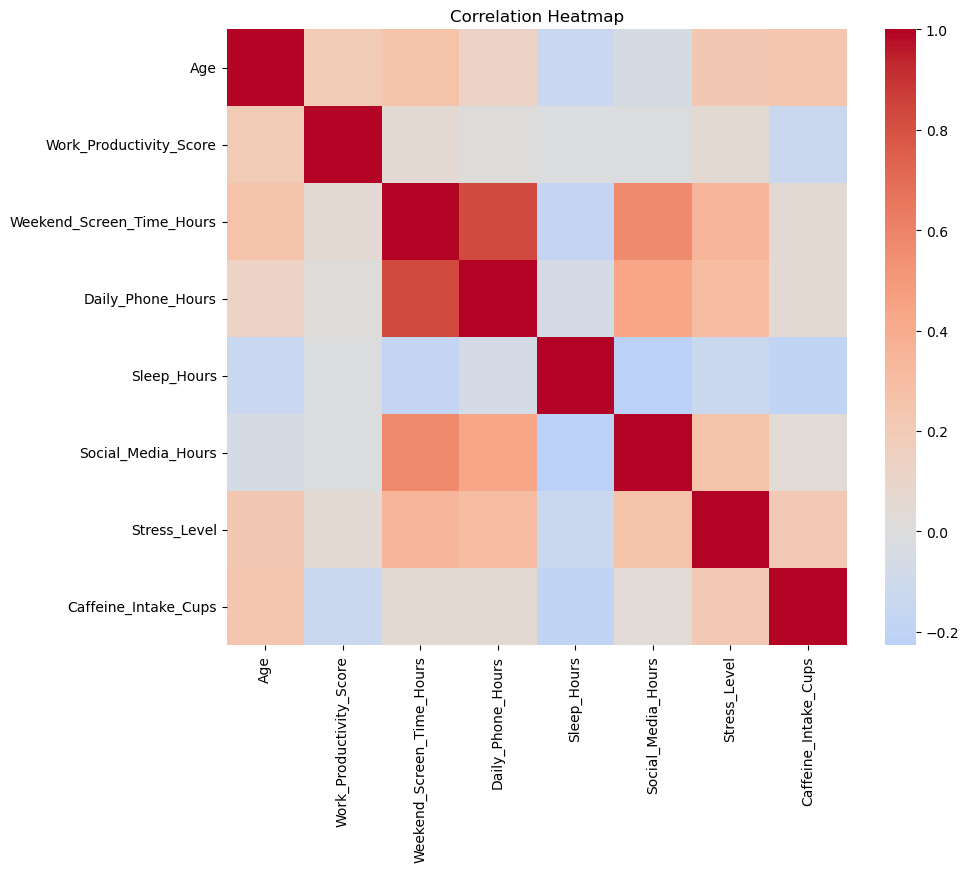

In [13]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

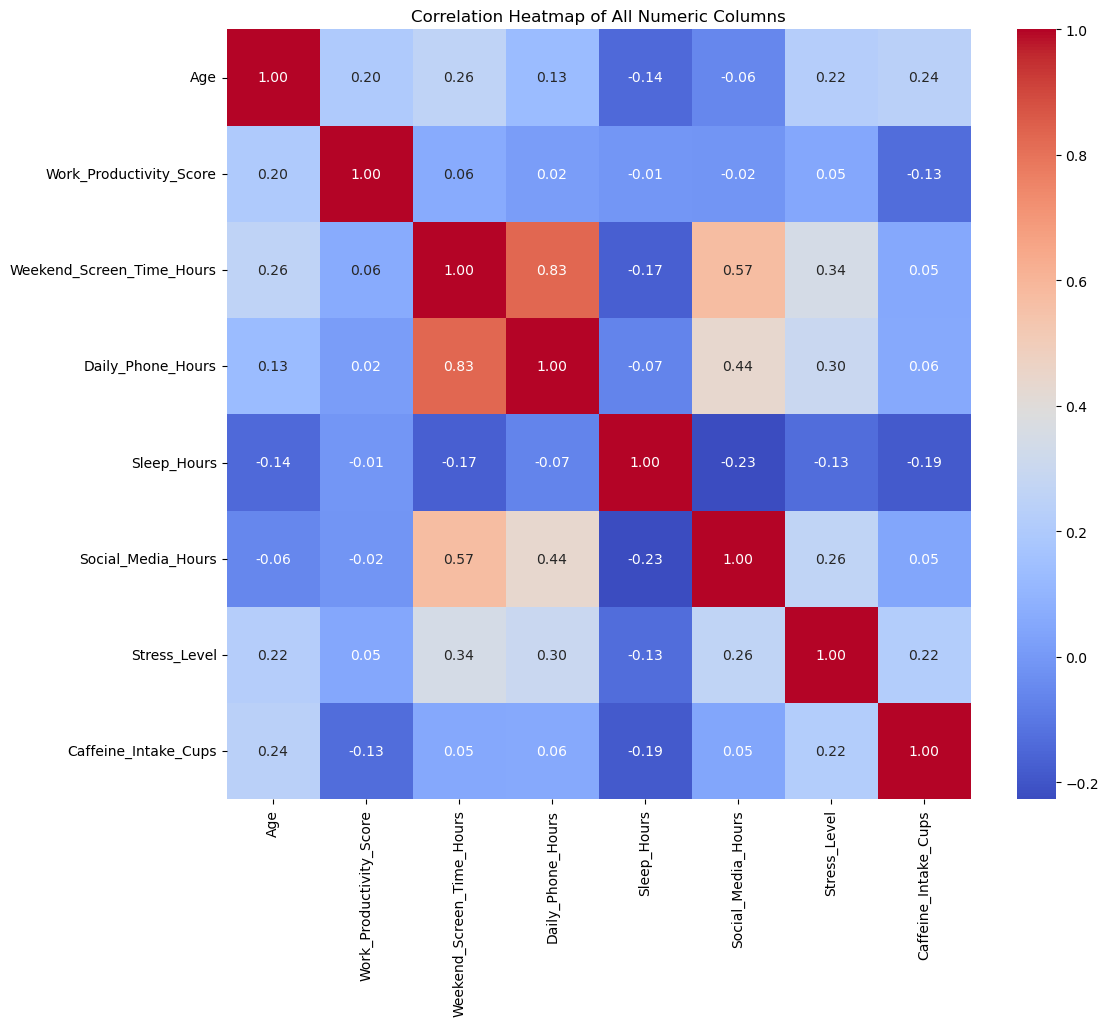

In [14]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of All Numeric Columns")
plt.show()

In [21]:
# Correlation with stress
stress_corr = corr_matrix["Stress_Level"].sort_values(ascending=False)

print("Correlation with Stress_Level:\n")
print(stress_corr)

Correlation with Stress_Level:

Stress_Level                 1.000000
Weekend_Screen_Time_Hours    0.344103
Daily_Phone_Hours            0.298273
Social_Media_Hours           0.264857
Age                          0.222637
Caffeine_Intake_Cups         0.217735
Work_Productivity_Score      0.046374
Sleep_Hours                 -0.134596
Name: Stress_Level, dtype: float64


Top correlated features: Index(['Weekend_Screen_Time_Hours', 'Daily_Phone_Hours', 'Social_Media_Hours',
       'Age'],
      dtype='object')


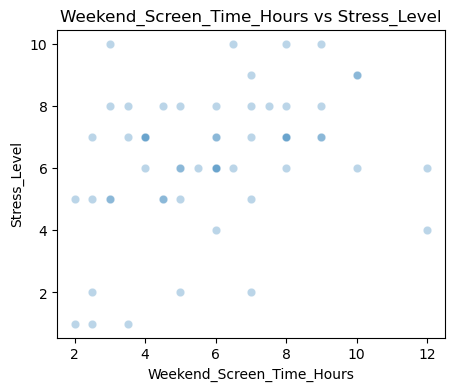

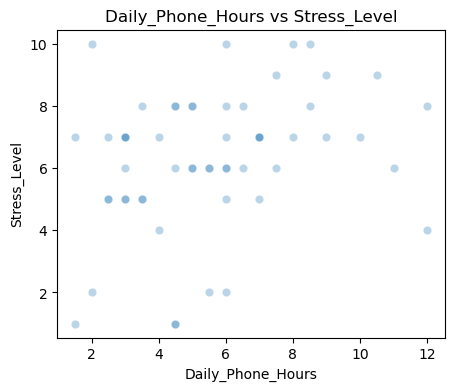

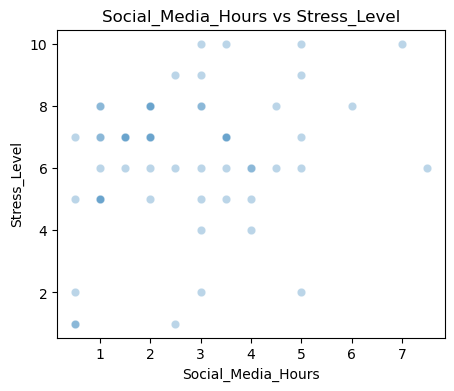

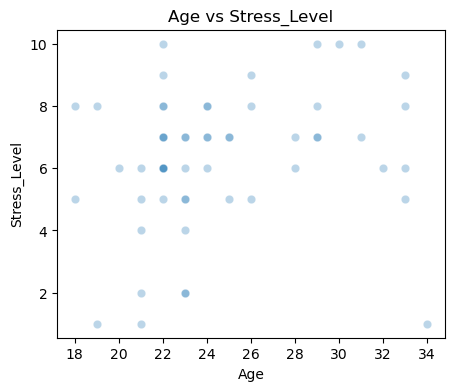

In [22]:
top_features = stress_corr.drop("Stress_Level").abs().sort_values(ascending=False).head(4).index

print("Top correlated features:", top_features)

for feature in top_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[feature], y=df["Stress_Level"], alpha=0.3)
    plt.title(f"{feature} vs Stress_Level")
    plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop target and ID
X = df[numeric_cols].drop(columns=["Stress_Level"])

# Add constant for VIF calculation
X_const = pd.concat([pd.Series(1, index=X.index, name="Intercept"), X], axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) 
                   for i in range(X_const.shape[1])]

vif_data

,Feature,VIF
0,Intercept,82.147041
1,Age,1.193607
2,Work_Productivity_Score,1.115248
3,Weekend_Screen_Time_Hours,4.279163
4,Daily_Phone_Hours,3.700648
5,Sleep_Hours,1.263727
6,Social_Media_Hours,1.483654
7,Caffeine_Intake_Cups,1.102647


In [23]:
from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=["Gender", "Occupation", "Device_Type", "Stress_Level"])
y = df["Stress_Level"]

mi_scores = mutual_info_regression(X, y)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
}).sort_values(by="Mutual_Information", ascending=False)

mi_df

,Feature,Mutual_Information
3,Daily_Phone_Hours,0.219450
2,Weekend_Screen_Time_Hours,0.093661
4,Sleep_Hours,0.065588
0,Age,0.000000
1,Work_Productivity_Score,0.000000
5,Social_Media_Hours,0.000000
6,Caffeine_Intake_Cups,0.000000


<h3> Treating Outliers 